# Counterfactual Explanation in Allegro Pay

**Warsaw University of Technology — Final Project**

---

This notebook provides boilerplate code to help you get started. It covers:

1. Environment verification & imports
2. Data loading & initial EDA
3. Feature engineering (skeleton)
4. Feature selection (Boruta)
5. Model training (LightGBM)
6. Model serialization
7. Counterfactual generation (DiCE & Alibi)
8. Evaluation & Benchmarking (DALEX)

> **Instructions:** Fork this repo, fill in the `TODO` sections, and extend the analysis.
> Delete or modify this boilerplate as your project evolves.

In [ ]:
#to dump w buszu
#pip freeze > reqirements.txt

#to install dependencies 
pip install -r requirements.txt

## 1. Imports & Configuration

In [43]:
# Standard library
import pickle
import warnings
from pathlib import Path

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import optbinning
# Modeling
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    average_precision_score,
    precision_recall_curve
)
#import lightgbm as lgb
import xgboost as xgb    # Uncomment if using XGBoost
# import catboost as cb     # Uncomment if using CatBoost

# Counterfactual Explanation packages
import dice_ml
# import alibi               # Uncomment when implementing Alibi

# Project config
import sys
sys.path.insert(0, str(Path.cwd().parent))  # Allow imports from src/
from src.config import (
    RANDOM_SEED,
    DATA_DIR,
    MODELS_DIR,
    TARGET_COLUMN,
    TEST_SIZE,
    N_FEATURES_TO_SELECT,
    N_COUNTERFACTUAL_EXAMPLES,
)

import subprocess
import zipfile

# Reproducibility
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore")

# Plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

print(f"Random seed: {RANDOM_SEED}")
print(f"Data directory: {DATA_DIR}")
print(f"Models directory: {MODELS_DIR}")

Random seed: 42
Data directory: C:\Users\stani\wut-counterfactual-explanations\data
Models directory: C:\Users\stani\wut-counterfactual-explanations\models


## 2. Data Loading & Initial EDA

Make sure you have downloaded the data from Kaggle into the `data/` directory.
See the README for download instructions.

In [2]:
# Load the main application training data
app_train = pd.read_csv(DATA_DIR / "application_train.csv")
pd.set_option('display.max_columns', 500)
print(f"Shape: {app_train.shape}")
print(f"\nTarget distribution:\n{app_train[TARGET_COLUMN].value_counts(normalize=True)}")
# Można też 'TARGET'
app_train.head()

Shape: (307511, 122)

Target distribution:
TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [3]:
bureau = pd.read_csv(DATA_DIR / "bureau.csv")
bureau = bureau[bureau['CREDIT_CURRENCY'] == 'currency 1']
bureau = bureau.drop(columns=['CREDIT_CURRENCY', 'SK_ID_BUREAU'])

num_cols_bureau = bureau.select_dtypes(include='number').columns.drop(['SK_ID_CURR'], errors='ignore').tolist()
cat_cols_bureau = ['CREDIT_ACTIVE', 'CREDIT_TYPE']

num_agg_bureau = bureau.groupby('SK_ID_CURR')[num_cols_bureau].agg(['max', 'sum', 'median', 'std', 'count'])
num_agg_bureau.columns = ['_'.join(col) for col in num_agg_bureau.columns]

cat_agg_bureau = pd.DataFrame(index=bureau['SK_ID_CURR'].unique())
for col in cat_cols_bureau:
    dummies = pd.get_dummies(bureau[['SK_ID_CURR', col]], columns=[col], dummy_na=True)
    cat_agg_bureau = cat_agg_bureau.join(dummies.groupby('SK_ID_CURR').sum())

bureau_agg = num_agg_bureau.join(cat_agg_bureau)

bureau_agg = bureau_agg.reset_index()
bureau_agg = bureau_agg.rename(columns={col: f"{col}_bureau" for col in bureau_agg.columns if col != 'SK_ID_CURR'})

In [4]:
credit_card_balance = pd.read_csv(DATA_DIR / "credit_card_balance.csv")
credit_card_balance = credit_card_balance.drop(columns=['NAME_CONTRACT_STATUS'])
# To ta jedyna kategoryczna
credit_card_balance.groupby('SK_ID_PREV')['SK_ID_CURR'].nunique().max() == 1

np.True_

In [5]:
credit_card_balance.groupby('SK_ID_CURR')['SK_ID_PREV'].nunique().max() == 1

np.False_

In [6]:
# WNIOSEK: JEDNO NOWE ID MOGŁO MIEĆ KILKA STARYCH, ALE JEDNO STARE NIE TWORZY RÓŻNYCH NOWYCH.
# Ale w sumie to nie ma znaczenia, bo i tak tego z niczym nie łączymy po tych starych id.

In [7]:
# Teraz agregujemy credit_card_balance

In [6]:
credit_card_balance = credit_card_balance.drop(columns=['SK_ID_PREV'])
num_cols_credit = credit_card_balance.select_dtypes(include='number').columns.drop(['SK_ID_CURR'], errors='ignore').tolist()

num_agg_credit = credit_card_balance.groupby('SK_ID_CURR')[num_cols_credit].agg(['max', 'sum', 'median', 'std', 'count'])
num_agg_credit.columns = ['_'.join(col) for col in num_agg_credit.columns]

credit_agg = num_agg_credit.reset_index()
credit_agg = credit_agg.rename(columns={col: f"{col}_credit" for col in credit_agg.columns if col != 'SK_ID_CURR'})

In [9]:
# instalments_payments nie miało żadnego znaczenia

In [7]:
pos_cash_balance = pd.read_csv(DATA_DIR / "POS_CASH_balance.csv")
pos_cash_balance = pos_cash_balance.drop(columns=['NAME_CONTRACT_STATUS'])
# To ta jedyna kategoryczna
pos_cash_balance.groupby('SK_ID_PREV')['SK_ID_CURR'].nunique().max() == 1

np.True_

In [8]:
pos_cash_balance.groupby('SK_ID_CURR')['SK_ID_PREV'].nunique().max() == 1

np.False_

In [9]:
pos_cash_balance = pos_cash_balance.drop(columns=['SK_ID_PREV'])
num_cols_pos = pos_cash_balance.select_dtypes(include='number').columns.drop(['SK_ID_CURR'], errors='ignore').tolist()

num_agg_pos = pos_cash_balance.groupby('SK_ID_CURR')[num_cols_pos].agg(['max', 'sum', 'median', 'std', 'count'])
num_agg_pos.columns = ['_'.join(col) for col in num_agg_pos.columns]

pos_agg = num_agg_pos.reset_index()
pos_agg = pos_agg.rename(columns={col: f"{col}_pos" for col in pos_agg.columns if col != 'SK_ID_CURR'})

In [10]:
previous_application = pd.read_csv(DATA_DIR / "previous_application.csv")
previous_application.groupby('SK_ID_PREV')['SK_ID_CURR'].nunique().max() == 1

np.True_

In [11]:
previous_application = previous_application.drop(columns=['SK_ID_PREV'])
num_cols_previous = previous_application.select_dtypes(include='number').columns.drop('SK_ID_CURR', errors='ignore').tolist()
cat_cols_previous = previous_application.select_dtypes(include='object').columns.drop('SK_ID_CURR', errors='ignore').tolist()

# numeric
num_agg_previous = previous_application.groupby('SK_ID_CURR')[num_cols_previous].agg(['max', 'mean', 'median', 'sum', 'std', 'count'])
num_agg_previous.columns = ['_'.join(col) for col in num_agg_previous.columns]

# categorical: count per category
cat_agg_previous = pd.DataFrame(index=previous_application['SK_ID_CURR'].unique())
for col in cat_cols_previous:
    dummies = pd.get_dummies(previous_application[['SK_ID_CURR', col]], columns=[col], dummy_na=True)
    cat_agg_previous = cat_agg_previous.join(dummies.groupby('SK_ID_CURR').sum())

previous_agg = num_agg_previous.join(cat_agg_previous)

previous_agg = previous_agg.reset_index()
previous_agg = previous_agg.rename(columns={col: f"{col}_previous" for col in previous_agg.columns if col != 'SK_ID_CURR'})

In [12]:
final_df = app_train.merge(bureau_agg, on='SK_ID_CURR', how='left')\
    .merge(credit_agg, on='SK_ID_CURR', how='left') \
                   .merge(pos_agg, on='SK_ID_CURR', how='left') \
                       .merge(previous_agg, on='SK_ID_CURR', how='left')

# Quick overview of missing values
missing_pct = (app_train.isnull().sum() / len(app_train) * 100).sort_values(ascending=False)
print(f"Columns with >50% missing:\n{missing_pct[missing_pct > 50]}")

# Target distribution visualization
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
app_train[TARGET_COLUMN].value_counts().plot(kind="bar", ax=ax, color=["steelblue", "coral"])
ax.set_title("Target Distribution (0 = No Default, 1 = Default)")
ax.set_xlabel("TARGET")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

In [ ]:
# TODO: More EDA (correlations, distributions, etc.)

app_train.columns

sample_df = app_train.sample(n=15000, random_state=RANDOM_SEED)  # sample 10k rows
sample_df = sample_df.dropna()  # drop rows with missing values for simplicity
for col in sample_df.columns:
    if sample_df[col].dtype in ['int64', 'float64']:  # numeric columns
        plt.figure(figsize=(6,4))
        sns.histplot(sample_df[col], kde=True, color='skyblue')
        plt.title(col)
        plt.show()

In [13]:
from optbinning import BinningProcess

In [14]:
# 1. Najpierw podzielmy zbiór na train i test. Dalej będziemy patrzeć na X_train.
X = final_df.drop(columns=['TARGET', 'SK_ID_CURR'])
y = final_df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

# 2. Definiujemy zmienne kategoryczne. I listę nazw wszystkich kolumn.
categorical_vars = [col for col in app_train.columns if app_train[col].dtype == 'object'] 
variable_names = X_train.columns.tolist()

custom_params = {
    "gamma": 0.1,               
    
    "outlier_detector": "zscore" 
}

# 2.Tworzymy słownik, w którym key to kolejne elementy variable_names a wartości to custom_params
binning_fit_params = {col: custom_params for col in variable_names}

# 3. Optimal Binning
binning_process = BinningProcess(
    variable_names=variable_names,
    categorical_variables=categorical_vars,
    binning_fit_params=binning_fit_params, # Tutaj korzystamy z powyżej zdefiniowanego binning_fit_params
    max_n_bins=8,          # Więcej niż domyślnie, bo domyślnie jest 5.
    min_bin_size=0.05,  
    selection_criteria={"iv": {"min": 0.005}})

# 4.Fit tylko na zbiorze treningowym, ale przekształcenia stosujemy na obu.
binning_process.fit(X_train, y_train)

X_train_woe = binning_process.transform(X_train)
X_test_woe = binning_process.transform(X_test)

In [15]:
summary = binning_process.summary()
# Poniżej wypiszemy te top 15 cech pod względem IV oraz ich IV
top_15_summary = summary.sort_values("iv", ascending=False).head(60)

# Print clearly with Name and IV score
print("--- Final Model: Top 15 Features ---")
print(top_15_summary[['name', 'iv']].reset_index(drop=True))

--- Final Model: Top 15 Features ---
                                       name        iv
0                              EXT_SOURCE_3  0.334562
1                              EXT_SOURCE_2  0.314303
2                              EXT_SOURCE_1  0.147214
3                 DAYS_CREDIT_median_bureau   0.12174
4          DAYS_CREDIT_UPDATE_median_bureau  0.096341
5                                DAYS_BIRTH   0.08679
6                    DAYS_CREDIT_max_bureau  0.084253
7                           AMT_GOODS_PRICE   0.08149
8         DAYS_CREDIT_ENDDATE_median_bureau  0.079426
9                           OCCUPATION_TYPE  0.078339
10                        ORGANIZATION_TYPE  0.069985
11          DAYS_ENDDATE_FACT_median_bureau  0.066248
12                            DAYS_EMPLOYED  0.062333
13           DAYS_CREDIT_ENDDATE_sum_bureau  0.062119
14             DAYS_ENDDATE_FACT_sum_bureau   0.05617
15    CNT_DRAWINGS_POS_CURRENT_count_credit  0.055451
16    CNT_DRAWINGS_ATM_CURRENT_count_credit  

In [16]:
# Dla zmiennych z IV około 0,03 jeszcze przedziały są sensowne, przykład:
for marker in ['FLOORSMAX_MEDI']:
    print(f"\n--- Binning Table: {marker} ---")
    table = binning_process.get_binned_variable(marker).binning_table.build()
    
    display_table = table[['Bin', 'Count', 'Event', 'Event rate', 'WoE']]
    print(display_table)


--- Binning Table: FLOORSMAX_MEDI ---
                 Bin   Count  Event  Event rate       WoE
0       (-inf, 0.16)   26073   2293    0.087945  -0.08594
1       [0.16, 0.20)   51144   3665    0.071660  0.136535
2        [0.20, inf)   42577   2494    0.058576   0.35214
3            Special       0      0    0.000000       0.0
4            Missing  122297  11228    0.091809 -0.133183
Totals                242091  19680    0.081292          


In [17]:
# Zwykle się usuwa to, co ma IV < 0,02, my usuniemy te o IV < 0,03, bo takich o IV 0,02-0,03 jest bardzo dużo
low_iv = summary[summary['iv'] < 0.03]['name'].tolist()
final_df_without_low_iv = final_df.drop(columns=low_iv)

In [18]:
final_df_without_low_iv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 71 columns):
 #   Column                                   Non-Null Count   Dtype  
---  ------                                   --------------   -----  
 0   SK_ID_CURR                               307511 non-null  int64  
 1   TARGET                                   307511 non-null  int64  
 2   AMT_CREDIT                               307511 non-null  float64
 3   AMT_GOODS_PRICE                          307233 non-null  float64
 4   NAME_INCOME_TYPE                         307511 non-null  object 
 5   DAYS_BIRTH                               307511 non-null  int64  
 6   DAYS_EMPLOYED                            307511 non-null  int64  
 7   DAYS_ID_PUBLISH                          307511 non-null  int64  
 8   OCCUPATION_TYPE                          211120 non-null  object 
 9   ORGANIZATION_TYPE                        307511 non-null  object 
 10  EXT_SOURCE_1                    

In [19]:
corr = final_df_without_low_iv.select_dtypes(include='number').corr()
pairs = corr.stack()
pairs = pairs[pairs.index.get_level_values(0) != pairs.index.get_level_values(1)]  # drop diagonal
pairs = pairs[pairs.index.get_level_values(0) < pairs.index.get_level_values(1)]   # drop duplicates
high_corr = pairs[pairs.abs() > 0.7].sort_values(ascending=False)
high_corr.to_csv('high_corr_pairs.csv')

In [20]:
to_drop = set()
for var1, var2 in high_corr[high_corr.abs() > 0.8].index:
    if var1 in to_drop or var2 in to_drop:
        continue
    # get IV for both
    iv1 = summary.loc[summary['name'] == var1, 'iv'].values[0]
    iv2 = summary.loc[summary['name'] == var2, 'iv'].values[0]
    # drop the weaker one
    if iv1 >= iv2:
        to_drop.add(var2)
    else:
        to_drop.add(var1)

print(f"Dropping {len(to_drop)} variables: {to_drop}")
final = final_df_without_low_iv.drop(columns=to_drop)

Dropping 26 variables: {'CNT_DRAWINGS_CURRENT_std_credit', 'DAYS_CREDIT_ENDDATE_max_bureau', 'AMT_RECEIVABLE_PRINCIPAL_sum_credit', 'CNT_DRAWINGS_POS_CURRENT_count_credit', 'AMT_TOTAL_RECEIVABLE_sum_credit', 'DAYS_CREDIT_UPDATE_sum_bureau', 'CNT_INSTALMENT_MATURE_CUM_max_credit', 'AMT_DRAWINGS_POS_CURRENT_count_credit', 'CNT_INSTALMENT_MATURE_CUM_median_credit', 'AMT_DRAWINGS_OTHER_CURRENT_count_credit', 'AMT_RECIVABLE_sum_credit', 'AMT_PAYMENT_CURRENT_sum_credit', 'DAYS_DECISION_median_previous', 'AMT_CREDIT_SUM_DEBT_max_bureau', 'AMT_DRAWINGS_CURRENT_sum_credit', 'CNT_INSTALMENT_MATURE_CUM_sum_credit', 'DAYS_FIRST_DUE_sum_previous', 'CNT_DRAWINGS_ATM_CURRENT_count_credit', 'FLOORSMAX_MEDI', 'DAYS_CREDIT_sum_bureau', 'CNT_INSTALMENT_MATURE_CUM_std_credit', 'AMT_CREDIT_SUM_DEBT_std_bureau', 'CNT_DRAWINGS_OTHER_CURRENT_count_credit', 'AMT_PAYMENT_CURRENT_count_credit', 'DAYS_FIRST_DUE_std_previous', 'AMT_CREDIT'}


In [21]:
final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 45 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   SK_ID_CURR                              307511 non-null  int64  
 1   TARGET                                  307511 non-null  int64  
 2   AMT_GOODS_PRICE                         307233 non-null  float64
 3   NAME_INCOME_TYPE                        307511 non-null  object 
 4   DAYS_BIRTH                              307511 non-null  int64  
 5   DAYS_EMPLOYED                           307511 non-null  int64  
 6   DAYS_ID_PUBLISH                         307511 non-null  int64  
 7   OCCUPATION_TYPE                         211120 non-null  object 
 8   ORGANIZATION_TYPE                       307511 non-null  object 
 9   EXT_SOURCE_1                            134133 non-null  float64
 10  EXT_SOURCE_2                            3068

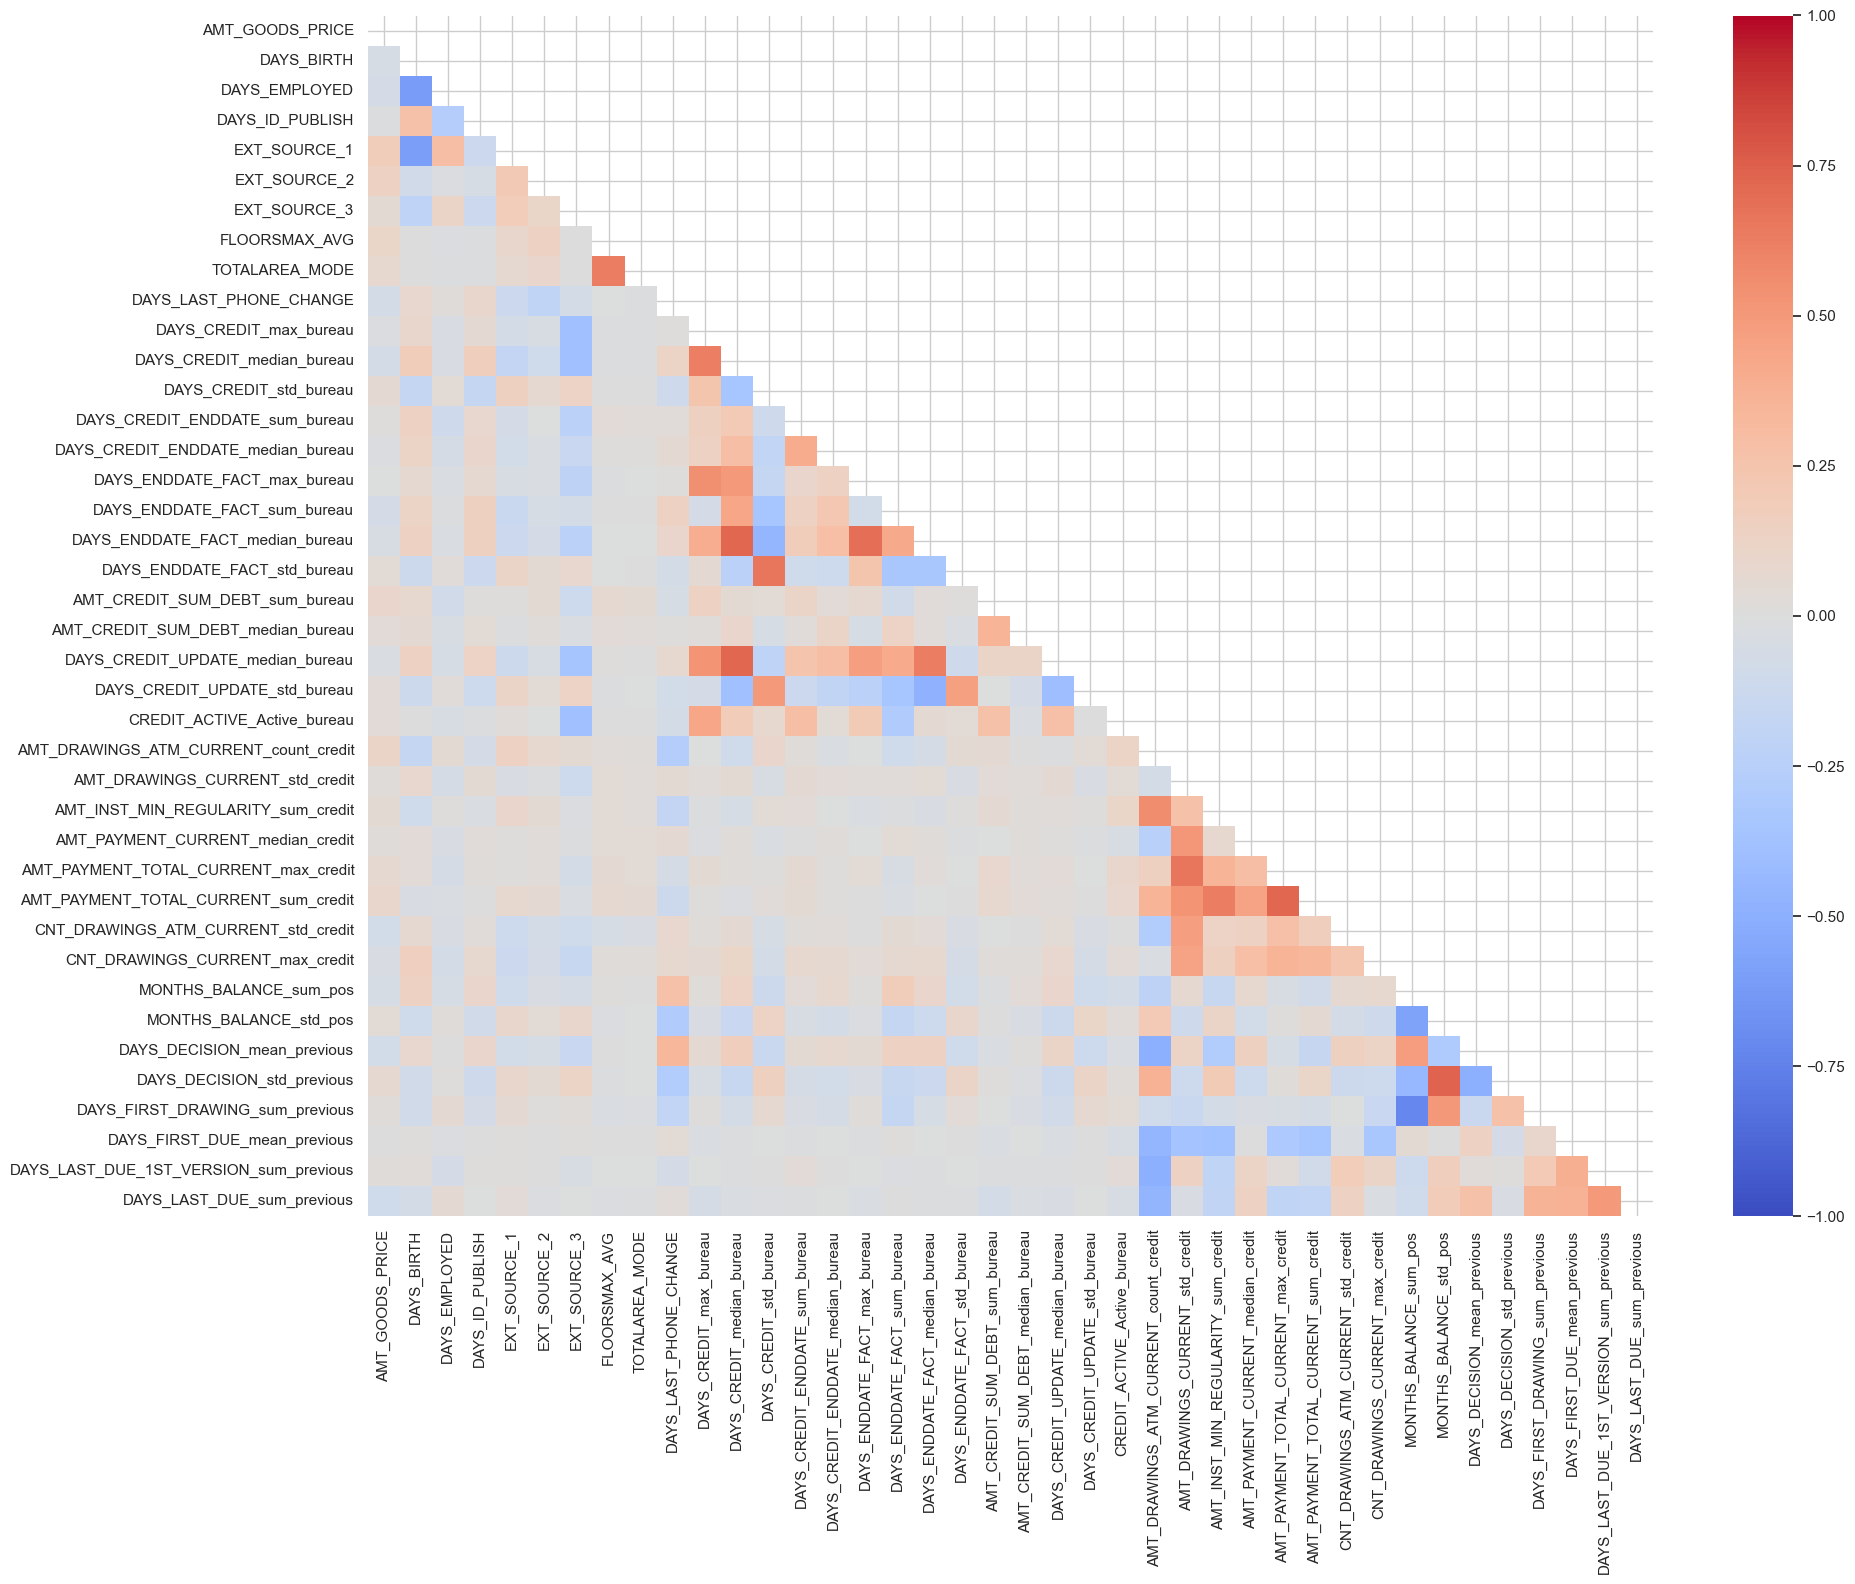

In [22]:
new_corr = final.drop(["TARGET", "SK_ID_CURR"], axis=1).select_dtypes(include="number").corr()
mask = np.triu(np.ones_like(new_corr, dtype=bool))

plt.figure(figsize=(20, 16))
sns.heatmap(new_corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1)
plt.tight_layout()
plt.savefig('corr_matrix.png', dpi=150)
plt.show()

In [26]:
# Boruta na tych 40. Najlepiej najpierw odrzucić te zmienne o bardzo niskich IV i silnie skorelowane a 
# potem robić Boruta na pozostałych.

In [23]:
from boruta import BorutaPy
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import numpy as np

In [28]:
# 300 000 wierszy to bardzo dużo, Boruta będzie się długo wykonywać.
# Sposób => sample 10 000 wierszy

In [24]:
X = pd.get_dummies(final.drop(["TARGET", "SK_ID_CURR"], axis=1))
feature_names = X.columns

print(X.min().min())
print(X.max().max())

# fillna wartością dużo poniżej minimum.
# W ten sposób Random Forest potraktuje braki danych jako osobną kategorię.
X = X.fillna(-99999999)

y = final["TARGET"].values

-6981558.210000001
334498331.20500004


In [25]:
from sklearn.utils import resample
# subsample 10,000 rows
X_sample, y_sample = resample(X, y, n_samples=10000, random_state=RANDOM_SEED, stratify=y)

rf = RandomForestClassifier(
    n_jobs=1,
    class_weight="balanced",
    max_depth=5,
    random_state=RANDOM_SEED
)

# z n_jobs=-1 byłoby szybciej, ale to zapewnia reproducibility

boruta = BorutaPy(
    estimator=rf,
    n_estimators="auto",
    max_iter=100,
    random_state=RANDOM_SEED
)

boruta.fit(X_sample.values, y_sample)

confirmed = feature_names[boruta.support_].tolist()
tentative = feature_names[boruta.support_weak_].tolist()

print(f"Confirmed: {len(confirmed)} features")
print(confirmed)
print(f"\nTentative: {len(tentative)} features")
print(tentative)

Confirmed: 23 features
['AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_LAST_PHONE_CHANGE', 'DAYS_CREDIT_max_bureau', 'DAYS_CREDIT_median_bureau', 'DAYS_CREDIT_std_bureau', 'DAYS_CREDIT_ENDDATE_sum_bureau', 'DAYS_CREDIT_ENDDATE_median_bureau', 'DAYS_CREDIT_UPDATE_median_bureau', 'DAYS_CREDIT_UPDATE_std_bureau', 'CNT_DRAWINGS_CURRENT_max_credit', 'MONTHS_BALANCE_sum_pos', 'MONTHS_BALANCE_std_pos', 'DAYS_DECISION_mean_previous', 'DAYS_DECISION_std_previous', 'DAYS_FIRST_DUE_mean_previous', 'DAYS_LAST_DUE_1ST_VERSION_sum_previous', 'DAYS_LAST_DUE_sum_previous']

Tentative: 0 features
[]


In [26]:
# Jeszcze raz, z innym random_state. Sprawdzimy, czy znalezione cechy się potwierdzą.
X_sample_2, y_sample_2 = resample(X, y, n_samples=10000, random_state=123, stratify=y)

rf_2 = RandomForestClassifier(
    n_jobs=1,
    class_weight="balanced",
    max_depth=5,
    random_state=RANDOM_SEED
)

# z n_jobs=-1 byłoby szybciej, ale to zapewnia reproducibility

boruta_2 = BorutaPy(
    estimator=rf_2,
    n_estimators="auto",
    max_iter=100,
    random_state=RANDOM_SEED
)

boruta_2.fit(X_sample_2.values, y_sample_2)

confirmed_2 = feature_names[boruta_2.support_].tolist()
tentative_2 = feature_names[boruta_2.support_weak_].tolist()

print(f"Confirmed: {len(confirmed_2)} features")
print(confirmed_2)
print(f"\nTentative: {len(tentative_2)} features")
print(tentative_2)

Confirmed: 20 features
['AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'DAYS_LAST_PHONE_CHANGE', 'DAYS_CREDIT_max_bureau', 'DAYS_CREDIT_median_bureau', 'DAYS_CREDIT_std_bureau', 'DAYS_CREDIT_ENDDATE_sum_bureau', 'DAYS_CREDIT_ENDDATE_median_bureau', 'DAYS_ENDDATE_FACT_std_bureau', 'AMT_CREDIT_SUM_DEBT_sum_bureau', 'DAYS_CREDIT_UPDATE_median_bureau', 'DAYS_CREDIT_UPDATE_std_bureau', 'CNT_DRAWINGS_ATM_CURRENT_std_credit', 'DAYS_DECISION_mean_previous', 'DAYS_LAST_DUE_1ST_VERSION_sum_previous']

Tentative: 1 features
['CNT_DRAWINGS_CURRENT_max_credit']


In [27]:
set1 = set(confirmed + tentative)
set2 = set(confirmed_2 + tentative_2)

only_in_first = set1 - set2
only_in_second = set2 - set1

print(f"Only in first run: {only_in_first}")
print(f"Only in second run: {only_in_second}")
print(f"\nIn both: {len(set1 & set2)} features")

Only in first run: {'MONTHS_BALANCE_sum_pos', 'DAYS_LAST_DUE_sum_previous', 'MONTHS_BALANCE_std_pos', 'DAYS_DECISION_std_previous', 'DAYS_FIRST_DUE_mean_previous'}
Only in second run: {'AMT_CREDIT_SUM_DEBT_sum_bureau', 'DAYS_ENDDATE_FACT_std_bureau', 'CNT_DRAWINGS_ATM_CURRENT_std_credit'}

In both: 18 features


In [33]:
# Wniosek: stabilny wybór, przy dwóch różnych random_state w większości te same cechy.
# Na wszelki wypadek weźmiemy sumę: te znalezione za pierwszym razem (confirmed+tentative) ∪ te znalezione za drugim razem (confirmed+tentative).

In [28]:
final_features = list(set(confirmed + tentative + confirmed_2 + tentative_2))
print(f"{len(final_features)} features selected")
print(final_features)

26 features selected
['DAYS_CREDIT_UPDATE_std_bureau', 'CNT_DRAWINGS_ATM_CURRENT_std_credit', 'AMT_CREDIT_SUM_DEBT_sum_bureau', 'AMT_GOODS_PRICE', 'DAYS_DECISION_std_previous', 'DAYS_CREDIT_ENDDATE_sum_bureau', 'DAYS_LAST_DUE_sum_previous', 'DAYS_EMPLOYED', 'DAYS_DECISION_mean_previous', 'EXT_SOURCE_2', 'DAYS_ID_PUBLISH', 'DAYS_CREDIT_std_bureau', 'DAYS_CREDIT_UPDATE_median_bureau', 'DAYS_CREDIT_median_bureau', 'DAYS_CREDIT_max_bureau', 'DAYS_LAST_PHONE_CHANGE', 'DAYS_ENDDATE_FACT_std_bureau', 'DAYS_FIRST_DUE_mean_previous', 'MONTHS_BALANCE_sum_pos', 'DAYS_BIRTH', 'EXT_SOURCE_3', 'MONTHS_BALANCE_std_pos', 'CNT_DRAWINGS_CURRENT_max_credit', 'DAYS_CREDIT_ENDDATE_median_bureau', 'DAYS_LAST_DUE_1ST_VERSION_sum_previous', 'EXT_SOURCE_1']


In [35]:
# Miało być 15-20, jest 26, czyli trochę za dużo. Usuniemy niektóre.

In [29]:
ranking_df = pd.DataFrame({
    "feature": feature_names,
    "rank_1": boruta.ranking_,
    "rank_2": boruta_2.ranking_
})

ranking_df = ranking_df[ranking_df["feature"].isin(final_features)]
ranking_df["avg_rank"] = (ranking_df["rank_1"] + ranking_df["rank_2"]) / 2
ranking_df = ranking_df.sort_values("avg_rank")

print(ranking_df)

                                   feature  rank_1  rank_2  avg_rank
0                          AMT_GOODS_PRICE       1       1       1.0
1                               DAYS_BIRTH       1       1       1.0
2                            DAYS_EMPLOYED       1       1       1.0
3                          DAYS_ID_PUBLISH       1       1       1.0
4                             EXT_SOURCE_1       1       1       1.0
5                             EXT_SOURCE_2       1       1       1.0
6                             EXT_SOURCE_3       1       1       1.0
9                   DAYS_LAST_PHONE_CHANGE       1       1       1.0
10                  DAYS_CREDIT_max_bureau       1       1       1.0
11               DAYS_CREDIT_median_bureau       1       1       1.0
12                  DAYS_CREDIT_std_bureau       1       1       1.0
13          DAYS_CREDIT_ENDDATE_sum_bureau       1       1       1.0
14       DAYS_CREDIT_ENDDATE_median_bureau       1       1       1.0
21        DAYS_CREDIT_UPDATE_media

In [37]:
# Boruta działa tak, że rank 1 to confirmed, rank 2 to tentative a im wyższy rank tym mniej użyteczne,
# ogólnie rank 3 to już uznane za bezużyteczne.
# Usuniemy kilka ostatnich cech, które mają niestabilny rank (raz 1 a raz 3 albo wyższy).
# W ten spsosób otrzymamy 19 stabilnych cech. W obu iteracjach przynajmniej rank 2. 

In [30]:
to_drop = ranking_df[
    ~((ranking_df["rank_1"].isin([1, 2])) & (ranking_df["rank_2"].isin([1, 2])))
]["feature"].tolist()
final_features = [f for f in final_features if f not in to_drop]
print(f"{len(final_features)} features remaining")

19 features remaining


In [31]:
print(final_features)

['DAYS_CREDIT_UPDATE_std_bureau', 'CNT_DRAWINGS_ATM_CURRENT_std_credit', 'AMT_GOODS_PRICE', 'DAYS_CREDIT_ENDDATE_sum_bureau', 'DAYS_EMPLOYED', 'DAYS_DECISION_mean_previous', 'EXT_SOURCE_2', 'DAYS_ID_PUBLISH', 'DAYS_CREDIT_std_bureau', 'DAYS_CREDIT_UPDATE_median_bureau', 'DAYS_CREDIT_median_bureau', 'DAYS_CREDIT_max_bureau', 'DAYS_LAST_PHONE_CHANGE', 'DAYS_BIRTH', 'EXT_SOURCE_3', 'CNT_DRAWINGS_CURRENT_max_credit', 'DAYS_CREDIT_ENDDATE_median_bureau', 'DAYS_LAST_DUE_1ST_VERSION_sum_previous', 'EXT_SOURCE_1']


In [32]:
final = final[final_features + ["TARGET", "SK_ID_CURR"]]

In [ ]:
###############################################################################################################################
###############################################################################################################################
###############################################################################################################################

In [33]:
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
import optuna

In [34]:
for col in final.select_dtypes(include='object').columns:
    final[col] = final[col].astype('category')
X = final.drop(columns=[TARGET_COLUMN, 'SK_ID_CURR'])
y = final[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

In [ ]:
ratio = len(final[final[TARGET_COLUMN] == 0]) / len(final[final[TARGET_COLUMN] == 1])

def objective(trial):

    params = {
        "objective": "binary:logistic",
        "eval_metric": "auc",

        "n_estimators": 3000,
        "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.13, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 8),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),

        "subsample": trial.suggest_float("subsample", 0.3, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1),

        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 1, 10),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 3),

        "scale_pos_weight": trial.suggest_float("scale_pos_weight", ratio - 0.01, ratio + 0.01),

        "tree_method": "hist"
    }

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

    aucs = []

    for train_idx, valid_idx in skf.split(X_train, y_train):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

        model = XGBClassifier(
            **params,
            enable_categorical=True,
            early_stopping_rounds=50
        )

        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            verbose=False
        )

        aucs.append(model.best_score)

    return np.mean(aucs)

In [40]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED)  
)

study.optimize(objective, n_trials=20)

[I 2026-04-13 21:24:07,381] A new study created in memory with name: no-name-91085799-ecf1-4940-9c90-42cc706f00b7
[I 2026-04-13 21:25:03,578] Trial 0 finished with value: 0.7505814367251838 and parameters: {'learning_rate': 0.047657531998729505, 'max_depth': 5, 'min_child_weight': 3, 'subsample': 0.37624972742578533, 'colsample_bytree': 0.9472665917141514, 'gamma': 3.1486425891349117, 'reg_lambda': 4.172668371255836, 'reg_alpha': 0.20261279809401256, 'scale_pos_weight': 11.389677062189703}. Best is trial 0 with value: 0.7505814367251838.
[I 2026-04-13 21:26:21,032] Trial 1 finished with value: 0.7519376235464172 and parameters: {'learning_rate': 0.07217083321329693, 'max_depth': 3, 'min_child_weight': 1, 'subsample': 0.4659925398096961, 'colsample_bytree': 0.694161468155265, 'gamma': 3.8718569103446443, 'reg_lambda': 1.383410179583408, 'reg_alpha': 1.0640858369354655, 'scale_pos_weight': 11.386533382424895}. Best is trial 1 with value: 0.7519376235464172.
[I 2026-04-13 21:26:59,758] Tr

In [41]:
best_params = study.best_params
model = XGBClassifier(
    enable_categorical=True,
    **best_params,
    n_estimators=3000,
    tree_method="hist"
)

with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

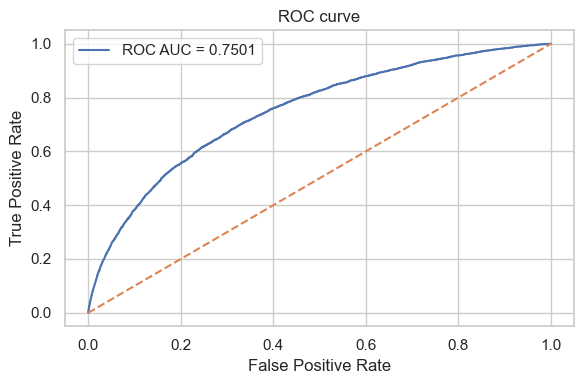

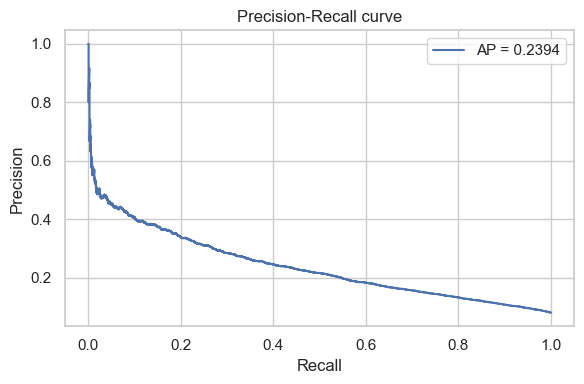

In [44]:
model.fit(X_train, y_train)
test_proba = model.predict_proba(X_test)[:, 1]

# Wykres ROC

fpr, tpr, _ = roc_curve(y_test, test_proba)
precision, recall, _ = precision_recall_curve(y_test, test_proba)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, test_proba):.4f}")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("ROC curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recall, precision, label=f"AP = {average_precision_score(y_test, test_proba):.4f}")
ax.set_title("Precision-Recall curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
###############################################################################################################################
###############################################################################################################################
###############################################################################################################################

In [45]:
app_train_TEST = app_train.copy()
for col in app_train_TEST.select_dtypes(include='object').columns:
    app_train_TEST[col] = app_train_TEST[col].astype('category')
X = app_train_TEST.drop(columns=[TARGET_COLUMN, 'SK_ID_CURR'])
y = app_train_TEST[TARGET_COLUMN]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)

In [46]:
model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8463396070697474
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import l

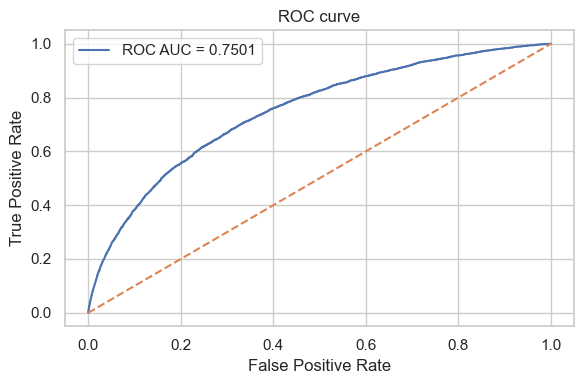

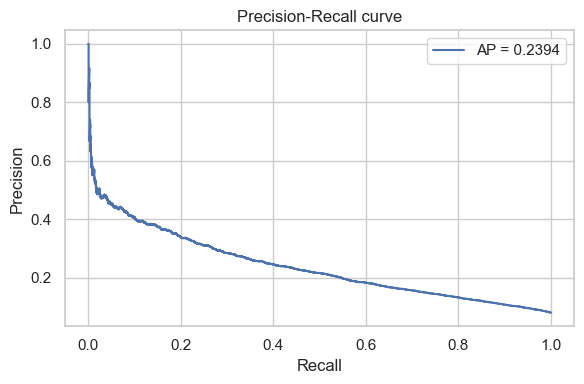

In [47]:
fpr, tpr, _ = roc_curve(y_test, test_proba)
precision, recall, _ = precision_recall_curve(y_test, test_proba)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, test_proba):.4f}")
ax.plot([0, 1], [0, 1], linestyle="--")
ax.set_title("ROC curve")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(recall, precision, label=f"AP = {average_precision_score(y_test, test_proba):.4f}")
ax.set_title("Precision-Recall curve")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
###############################################################################################################################
###############################################################################################################################
###############################################################################################################################

In [ ]:
# kolumny które mają sens - reszta to jakiś syf
selected_columns = [
    "SK_ID_CURR",
    "TARGET",
    "NAME_CONTRACT_TYPE",
    "CODE_GENDER",
    "FLAG_OWN_CAR",
    "FLAG_OWN_REALTY",
    "CNT_CHILDREN",
    "AMT_INCOME_TOTAL",
    "AMT_CREDIT",
    "AMT_ANNUITY",
    "AMT_GOODS_PRICE",
    "NAME_INCOME_TYPE",
    "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS",
    "NAME_HOUSING_TYPE",
    "REGION_POPULATION_RELATIVE",
    "DAYS_BIRTH",
    "DAYS_EMPLOYED",
    "DAYS_REGISTRATION",
    "DAYS_ID_PUBLISH",
    "OWN_CAR_AGE",
    "OCCUPATION_TYPE",
    "CNT_FAM_MEMBERS",
    "REGION_RATING_CLIENT_W_CITY",
    "OBS_60_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE"
]
app_train = app_train[selected_columns]

In [ ]:
numeric_df = app_train.select_dtypes(include=['number'])
corr = numeric_df.corr()

plt.figure(figsize=(20, 16))
sns.heatmap(corr, cmap='coolwarm', center=0, 
            xticklabels=True, yticklabels=True, 
            linewidths=0.5, annot = True)
plt.title("Correlation Matrix", fontsize=16)
plt.show()

In [ ]:
# patrząc na macierz korelacji wywalamy jeszcze następujące kolumny:
# AMT_GOODS_PRICE - bo mocno skorelowana z AMT_CREDIT
# CNT_CHILDREN - bo mocno skorelowana z CNT_FAM_MEMBERS (zostawiamy liczbę członków rodziny bo można nie mieć dzieci ale rodzinę już się pewnie jakąś ma)
app_train = app_train.drop(columns=["AMT_GOODS_PRICE", "CNT_CHILDREN"])

## 3. Feature Engineering

Create new features with **semantic, human-readable names**.

Example naming conventions:
- `income_to_credit_ratio` (not `feat_001`)
- `annuity_to_income_ratio` (not `ratio_2`)
- `bureau_active_credits_count` (not `bur_cnt`)

In [ ]:
# TODO: Load and aggregate supplementary data sources
bureau = pd.read_csv(DATA_DIR / "bureau.csv")
# 
# 
# pos_cash = pd.read_csv(DATA_DIR / "POS_CASH_balance.csv")
# installments = pd.read_csv(DATA_DIR / "installments_payments.csv")
# credit_card = pd.read_csv(DATA_DIR / "credit_card_balance.csv")

In [ ]:
bureau

In [ ]:
cols_to_delete = ['SK_ID_BUREAU', 'CREDIT_CURRENCY','CREDIT_DAY_OVERDUE','DAYS_CREDIT_ENDDATE', 'DAYS_ENDDATE_FACT', 'AMT_CREDIT_MAX_OVERDUE', 'CNT_CREDIT_PROLONG',
                  'AMT_CREDIT_SUM_DEBT','AMT_CREDIT_SUM_LIMIT', 'CREDIT_TYPE', 'DAYS_CREDIT_UPDATE', 'CNT_CREDIT_PROLONG' , 'AMT_CREDIT_SUM_LIMIT', 'AMT_CREDIT_SUM_OVERDUE', 'AMT_ANNUITY']
bureau = bureau[bureau["CREDIT_ACTIVE"] == "Active"].drop(columns=cols_to_delete).dropna()

In [ ]:
bureau["weighted_credit"] = bureau["AMT_CREDIT_SUM"] / bureau["DAYS_CREDIT"].abs()  
bureau.groupby("SK_ID_CURR")["weighted_credit"].sum().reset_index()

In [ ]:
sample_bureau = bureau.sample(n=30000, random_state=RANDOM_SEED)  # sample 10k rows
sample_bureau = sample_bureau.dropna()  # drop rows with missing values for simplicity
for col in sample_bureau.columns:
    if sample_bureau[col].dtype in ['int64', 'float64']:  # numeric columns
        plt.figure(figsize=(6,4))
        sns.histplot(sample_bureau[col], kde=True, color='skyblue')
        plt.title(col)
        plt.show()

In [ ]:
# Quick overview of missing values
missing_pct = (bureau.isnull().sum() / len(bureau) * 100).sort_values(ascending=False)
print(f"Columns with >50% missing:\n{missing_pct[missing_pct > 10]}")

In [ ]:
bureau_balance = pd.read_csv(DATA_DIR / "bureau_balance.csv")

In [ ]:
bureau_balance # --- IGNORE --- (syf)

In [ ]:
previous_app = pd.read_csv(DATA_DIR / "previous_application.csv")

In [ ]:
previous_app

In [ ]:
previous_app[previous_app["SK_ID_CURR"] == 100003]

In [ ]:
# --- Example feature engineering (extend this!) ---

df = app_train.copy()

# Ratio features (semantic names)
df["INCOME_TO_CREDIT_RATIO"] = df["AMT_INCOME_TOTAL"] / df["AMT_CREDIT"].replace(0, np.nan)
df["ANNUITY_TO_INCOME_RATIO"] = df["AMT_ANNUITY"] / df["AMT_INCOME_TOTAL"].replace(0, np.nan)
#df["CREDIT_TO_GOODS_RATIO"] = df["AMT_CREDIT"] / df["AMT_GOODS_PRICE"].replace(0, np.nan)
df["DAYS_EMPLOYED_RATIO"] = df["DAYS_EMPLOYED"] / df["DAYS_BIRTH"]

# External source aggregation
ext_cols = ["EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3"]
df["EXTERNAL_SOURCES_MEAN"] = df[ext_cols].mean(axis=1)
df["EXTERNAL_SOURCES_STD"] = df[ext_cols].std(axis=1)

# TODO: Add other aggregates

print(f"Shape after feature engineering: {df.shape}")
df.head()

In [ ]:
# TODO:Handle missing values and encode categoricals
# TODO: Implement proper imputation strategy

print(f"Shape after preprocessing: {df.shape}")

## 4. Feature Selection

Select **15–20 features** using Boruta or Best Subset Selection.
This reduces dimensionality and improves interpretability of counterfactuals.

In [ ]:
# TODO: Implement feature selection

selected_features = None

print(f"Selected {len(selected_features)} features:\n{selected_features}")

## 5. Model Training

Train a tree-based classifier. LightGBM is recommended, but you may also
try XGBoost or CatBoost.

**Important:** Use `RANDOM_SEED = 42` for all random operations.

In [ ]:
# Prepare features and target
X = df[selected_features]
y = df[TARGET_COLUMN]

# Train/test split with fixed seed
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED,
    stratify=y,
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train target rate: {y_train.mean():.4f}")
print(f"Test target rate:  {y_test.mean():.4f}")

In [ ]:
# TODO: Train classifier

model = None 

print("\nTraining complete!")

In [ ]:
# TODO: Evaluate the model

# TODO: Print Roc AUC

# TODO: Plot ROC curve


In [ ]:
masterscale = pd.DataFrame({
    "Rating": [
        "AAA", "AA+", "AA", "AA-",
        "A+", "A", "A-",
        "BBB+", "BBB", "BBB-",
        "BB+", "BB", "BB-",
        "B+", "B", "B-",
        "CCC", "CC", "C", "D",
    ],
    "PD_lower": [
        0.0000, 0.0002, 0.0004, 0.0008,
        0.0015, 0.0025, 0.0040,
        0.0060, 0.0100, 0.0150,
        0.0250, 0.0400, 0.0600,
        0.1000, 0.1500, 0.2000,
        0.3000, 0.4000, 0.5000, 0.7000,
    ],
    "PD_upper": [
        0.0002, 0.0004, 0.0008, 0.0015,
        0.0025, 0.0040, 0.0060,
        0.0100, 0.0150, 0.0250,
        0.0400, 0.0600, 0.1000,
        0.1500, 0.2000, 0.3000,
        0.4000, 0.5000, 0.7000, 1.0000,
    ],
})

print(masterscale)

# TODO: Visualise the distribution of predicted probabilities and overlay the rating thresholds

# TODO: Decide the decision threshold (as the end of some rating), such will classify at least 10% as bad.

decision_threshold = None

In [ ]:
# TODO: Calculate the classification metrics

# TODO: Precision, recall, F1-score, confusion matrix, etc.

In [ ]:
# TODO: Plot SHAP summary plot

Provide a quick discussion how model works "globally"

## 6. Model Serialization

Save the trained model as a `.pkl` file in the `models/` directory.
This file **must be committed** to the repository.

In [ ]:
# Save model
model_path = MODELS_DIR / "final_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(model, f)
print(f"Model saved to {model_path}")

# Verify: reload and check
with open(model_path, "rb") as f:
    loaded_model = pickle.load(f)
assert roc_auc_score(y_test, loaded_model.predict_proba(X_test)[:, 1]) == auc
print("Model verification passed!")

## 7. Counterfactual Analysis

### 7a. Select Interesting Test Examples

Choose 10–15 instances from the test set that are interesting for CE analysis:
- Near the decision boundary
- Correctly classified defaults
- Misclassified examples
- High-confidence edge cases

In [ ]:
# TODO: Select interesting examples based on prediction probability

interesting_examples = None

### 7b. DiCE — Diverse Counterfactual Explanations

Generate counterfactuals using the DiCE package.

Documentation: [github.com/interpretml/DiCE](https://github.com/interpretml/DiCE)

In [ ]:
# TODO: Implement DiCE counterfactual generation

### 7c. Alibi Explain — Counterfactual with Prototypes

Generate counterfactuals using the Alibi package.

Documentation: [docs.seldon.io/projects/alibi](https://docs.seldon.io/projects/alibi/en/stable/methods/CFProto.html)

In [ ]:
# TODO: Implement Alibi counterfactual generation

## 8. Evaluation & Benchmarking

In [ ]:
# TODO: Implement DiCE counterfactual generation

## 9. Summary & Next Steps

### What you have done:

---

### AI Tools Used

Document any AI tools used during this project:

| Tool | How it was used |
|------|----------------|
| *e.g., ChatGPT* | *e.g., Helped debug LightGBM hyperparameter tuning* |
| | |